<a href='https://www.hexnbit.com/'> <img src='https://www.hexnbit.com/wp-content/uploads/2019/09/hexnbit_final_66px.png'/> </a>

#                                       WHEAT SEED QUALITY DETECTION USING AI-ML

1. ETICALA SATWIK REDDY
2. MANTHENA KOUSHIK VARMA

### STEP 1:  Read Dataset

In [1]:
import pandas as pd
df = pd.read_csv ("wheat-seeds.csv")

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
coulmn_names=[ "area A","perimeter P","compactness C ","length of kernel","width of kernel","asymmetry coefficient","length of kernel groove","seed_type"] 
#naming the cloumns as per the data given.
df = pd.read_csv("wheat-seeds.csv", names=coulmn_names)
LABEL_MAP = {
    1: "white",
    2: "brown",
    3: "organic",
} 
"""In the given csv file, we are taking the last attribute as type of seed. We are labelling 1 as white, 2 as brown and 3 as
    organic.
"""
for k,v in LABEL_MAP.items():
    df.ix[df.seed_type == k, 'seed_type'] = v
df

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove,seed_type
0,15.26,14.84,0.8710,5.763,3.312,2.2210,5.220,white
1,14.88,14.57,0.8811,5.554,3.333,1.0180,4.956,white
2,14.29,14.09,0.9050,5.291,3.337,2.6990,4.825,white
3,13.84,13.94,0.8955,5.324,3.379,2.2590,4.805,white
4,16.14,14.99,0.9034,5.658,3.562,1.3550,5.175,white
5,14.38,14.21,0.8951,5.386,3.312,2.4620,4.956,white
6,14.69,14.49,0.8799,5.563,3.259,3.5860,5.219,white
7,14.11,14.10,0.8911,5.420,3.302,2.7000,5.000,white
8,16.63,15.46,0.8747,6.053,3.465,2.0400,5.877,white
9,16.44,15.25,0.8880,5.884,3.505,1.9690,5.533,white


***Hence we can conclude that there is "No" missing data.

In [4]:
df.groupby('seed_type')['seed_type'].count()  #number of seeds in each type

seed_type
brown      70
organic    70
white      70
Name: seed_type, dtype: int64

# STEP: 2:-Exploratory Data Analysis & Visulaization

Exploratory Data Analysis (EDA), also known as Data Exploration, is a step in the Data Analysis Process, where a number of techniques are used to better understand the dataset being used.


It includes:

==>Extracting important variables and leaving behind useless variables and Identifying outliers, missing values, or human error

==>Understanding the relationship(s), or lack of, between variables

==>Ultimately, maximizing your insights of a dataset and minimizing potential error that may occur later in the process

###### COMPONENTS OF EDA

1. UNDERSTANDING THE VARIABLES
2. CLEANSING DATASET
3. ANALYZING RELATIONSHIPS BETWEEN VARIABLES

###### 1. UNDERSTANDING THE VARIABLES

In [5]:
# importing the required libraries
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pylab as plt
import seaborn as sns

In [6]:
#understanding variables
df.head() #returns the first 5 rows of my dataset

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove,seed_type
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,white
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,white
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,white
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,white
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,white


In [7]:
df.tail()  #returns the last 5 rows of my dataset

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove,seed_type
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,organic
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,organic
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,organic
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,organic
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,organic


In [8]:
df.columns #returns the names of the columns of my dataset

Index(['area A', 'perimeter P', 'compactness C ', 'length of kernel',
       'width of kernel', 'asymmetry coefficient', 'length of kernel groove',
       'seed_type'],
      dtype='object')

In [9]:
df.shape #returns the number of rows by the number of columns of dataset

(210, 8)

In [10]:
df.describe()   #summarizes the count, mean, standard deviation, min and max for numeric variables

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


In [11]:
df.nunique(axis=0) #returns the number of unique vlaues for each variable

area A                     193
perimeter P                170
compactness C              186
length of kernel           188
width of kernel            184
asymmetry coefficient      207
length of kernel groove    148
seed_type                    3
dtype: int64

###### 2. Cleansing the dataset--checking for missing values

CHECKING ROWS WITH NULL VALUES

In [12]:
df.isnull() #checking for null values

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove,seed_type
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False


No null values have been found.

###### 3.Analyzing relationships between variables

Correlation matrix

Correlation matrix is a table that shows the correlation coefficients between many variables

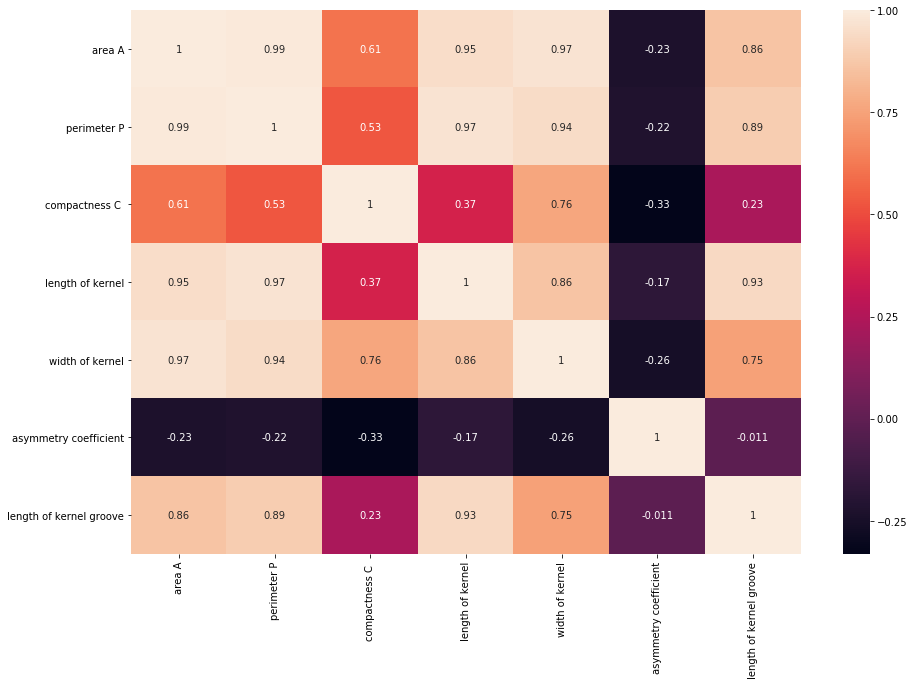

In [13]:
import seaborn as sns
#plotting the correlation matrix using sns.heatmap()
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

Scatterplot

A scatterplot is a type of graph which ‘plots’ the values of two variables along two axes, like age and height.

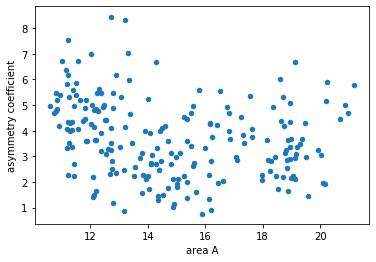

In [14]:
df.plot(kind='scatter', x='area A', y='asymmetry coefficient')

The above scatterplot will make us understand about, how area is effecting the assymetry coefficient of a wheat grain.

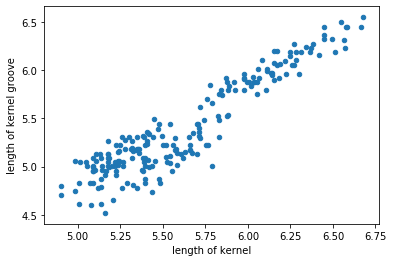

In [15]:
df.plot(kind='scatter', x='length of kernel', y='length of kernel groove')

The above plot will give a clear understanding how the length of kernel is showing its effect on lenghth of kernel groove.

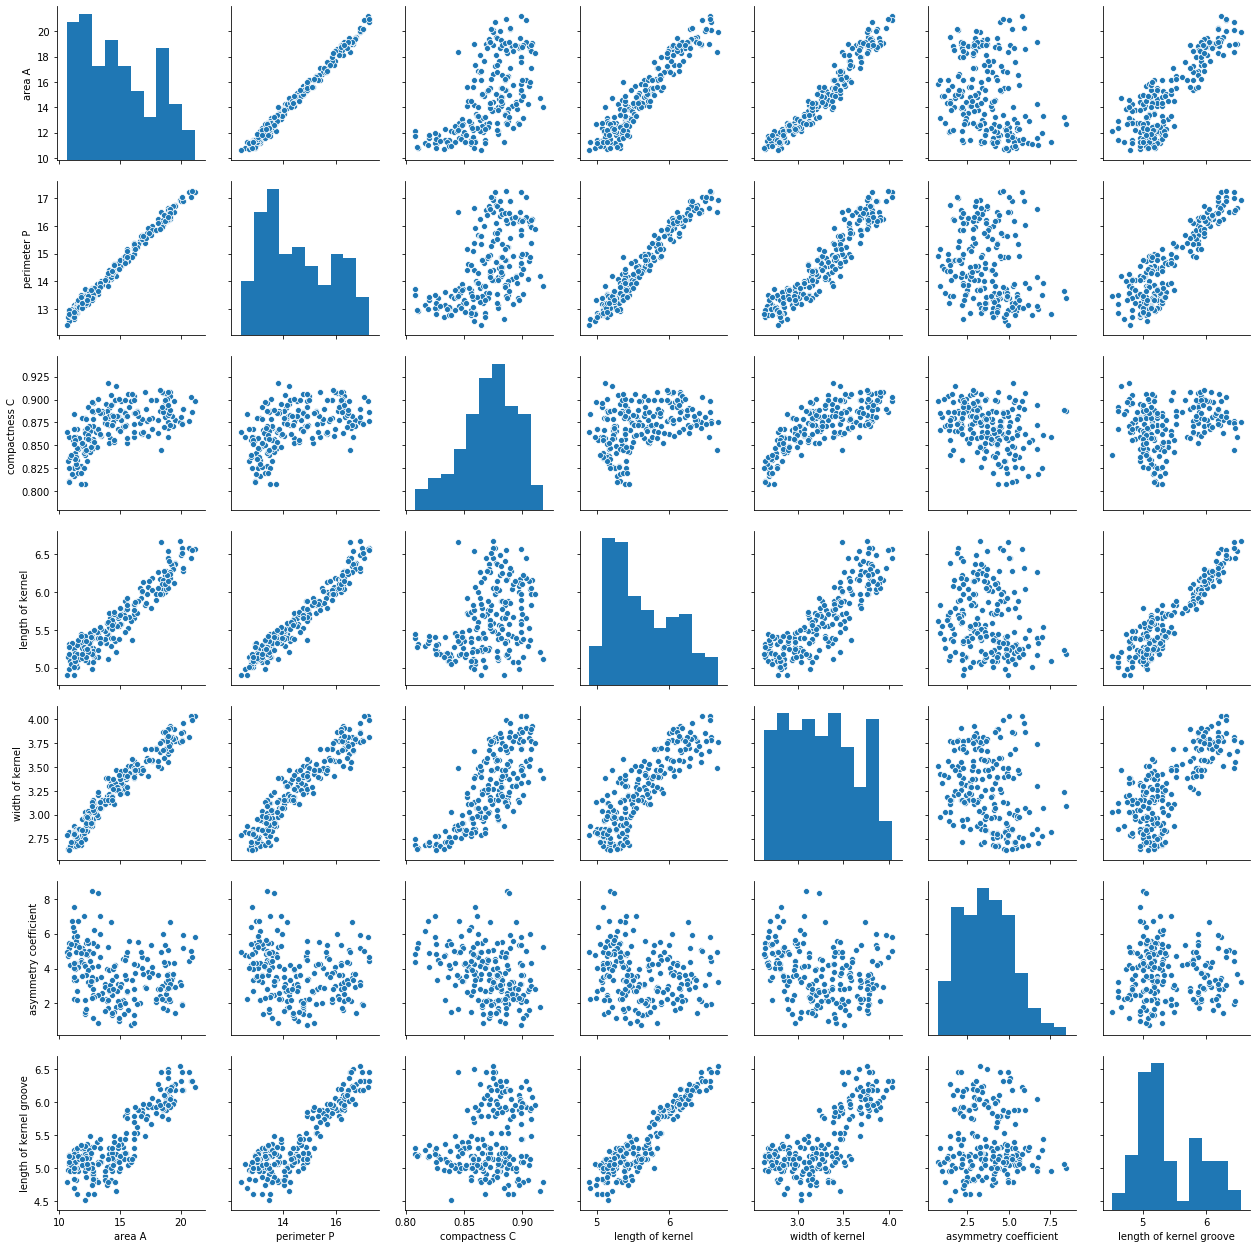

In [16]:
sns.pairplot(df) #creating scatterplots between all the variables

Parallel coordinates

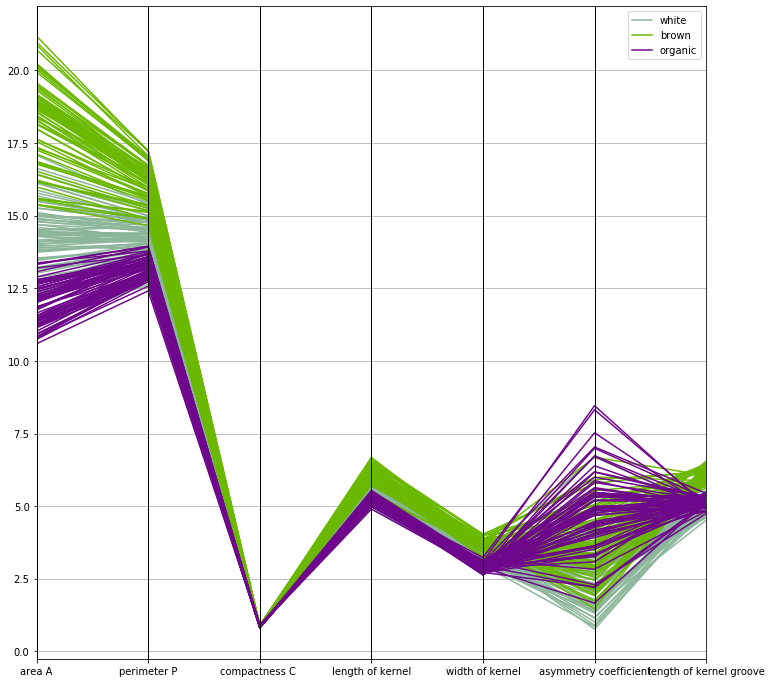

In [17]:
from pandas.plotting import parallel_coordinates
plt.figure(figsize=(12,12))
parallel_coordinates(df, 'seed_type')
plt.show()


The above graph will show the comparison between various variables with the type of seed, i.e white,brown and organic
parallely in a single graph.

### 3.Split Data for Training and Testing

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(df.drop('seed_type',axis=1), 
                                                    df['seed_type'], test_size=0.30, 
                                                    random_state=101)

In [20]:
x_train   #Data for training

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
33,13.94,14.17,0.8728,5.585,3.150,2.124,5.012
45,13.80,14.04,0.8794,5.376,3.155,1.560,4.961
196,12.79,13.53,0.8786,5.224,3.054,5.483,4.958
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044
53,14.33,14.28,0.8831,5.504,3.199,3.328,5.224
93,18.59,16.05,0.9066,6.037,3.860,6.001,5.877
100,16.41,15.25,0.8866,5.718,3.525,4.217,5.618
165,12.10,13.15,0.8793,5.105,2.941,2.201,5.056
150,11.83,13.23,0.8496,5.263,2.840,5.195,5.307
155,11.19,13.05,0.8253,5.250,2.675,5.813,5.219


In [21]:
x_test  #splitting data for testing

,area A,perimeter P,compactness C,length of kernel,width of kernel,asymmetry coefficient,length of kernel groove
123,18.43,15.97,0.9077,5.980,3.771,2.9840,5.905
134,15.56,14.89,0.8823,5.776,3.408,4.9720,5.847
184,12.89,13.77,0.8541,5.495,3.026,6.1850,5.316
125,18.75,16.18,0.8999,6.111,3.869,4.1880,5.992
189,10.59,12.41,0.8648,4.899,2.787,4.9750,4.794
154,11.36,13.05,0.8382,5.175,2.755,4.0480,5.263
188,11.23,12.82,0.8594,5.089,2.821,7.5240,4.957
89,20.88,17.05,0.9031,6.450,4.032,5.0160,6.321
37,17.08,15.38,0.9079,5.832,3.683,2.9560,5.484
34,15.05,14.68,0.8779,5.712,3.328,2.1290,5.360


### 4.Apply different Classification Algorithms and tune them

 support vector machine

In [22]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
predictions=model.predict(x_test)

K nearest neighbours 

In [23]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

Decision Trees

In [24]:
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier(max_depth = 6,random_state = 0,criterion = "entropy")
model1.fit(x_train, y_train)
predictions2=model1.predict(x_test)

Logistic Regression

In [25]:

from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(max_iter=800)
logmodel = LogisticRegression(solver='liblinear')
logmodel.fit(x_train,y_train)
predictions1 = logmodel.predict(x_test)

 Hyper parameter tuning in support Vector machine

In [26]:
 
from sklearn.model_selection import GridSearchCV
grid_parameters = {'C': [0.001,0.1,1, 10, 100, 1000], 'gamma': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]} 
grid = GridSearchCV(SVC(),grid_parameters,verbose=1)
grid.fit(x_train,y_train)
grid_predictions = grid.predict(x_test)

Fitting 3 folds for each of 42 candidates, totalling 126 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 126 out of 126 | elapsed:    0.4s finished
C:\Users\ETICALA SATWIK REDDY\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


Hyper parameter tuning in Logistic regression

In [27]:

from sklearn.model_selection import GridSearchCV
params = {'penalty' : ['l1', 'l2'],'C' : np.logspace(-4, 4, 20),'solver' : ['liblinear']}
grid1 = GridSearchCV(LogisticRegression(),params,verbose=1)
grid1.fit(x_train,y_train)
grid_predictions1 = grid1.predict(x_test)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Fitting 3 folds for each of 40 candidates, totalling 120 fits


[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:    3.2s finished
C:\Users\ETICALA SATWIK REDDY\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


 Hyper paramter tuning in K nearest neighbours

In [28]:
from sklearn.model_selection import GridSearchCV
params =  {
    'n_neighbors': (1,10, 1),
    'leaf_size': (20,40,1),
    'p': (1,2),
    'weights': ('uniform', 'distance'),
    'metric': ('minkowski', 'chebyshev')}
grid2 = GridSearchCV(KNeighborsClassifier(),params,verbose=1)
grid2.fit(x_train,y_train)
grid_predictions2 = grid2.predict(x_test)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 216 out of 216 | elapsed:    0.7s finished
C:\Users\ETICALA SATWIK REDDY\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


#### 5.PERFORAMANCE METRICS

In [29]:
from sklearn.metrics import classification_report

In [30]:
#---------------SUPPORT VECTOR MACHINE ---------------#
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

       brown       0.83      1.00      0.91        15
     organic       0.88      1.00      0.94        22
       white       1.00      0.77      0.87        26

    accuracy                           0.90        63
   macro avg       0.90      0.92      0.90        63
weighted avg       0.92      0.90      0.90        63



In [31]:
#-----------LOGISTIC REGRESSION--------------#

print(classification_report(y_test,predictions1))

              precision    recall  f1-score   support

       brown       0.83      1.00      0.91        15
     organic       0.92      1.00      0.96        22
       white       1.00      0.81      0.89        26

    accuracy                           0.92        63
   macro avg       0.92      0.94      0.92        63
weighted avg       0.93      0.92      0.92        63



In [32]:
#---------------Descision Tree---------------#
print(classification_report(y_test,predictions2))

              precision    recall  f1-score   support

       brown       1.00      1.00      1.00        15
     organic       0.88      0.95      0.91        22
       white       0.96      0.88      0.92        26

    accuracy                           0.94        63
   macro avg       0.94      0.95      0.94        63
weighted avg       0.94      0.94      0.94        63



In [33]:
# ---------- nearest neighbors --------------------#

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       brown       0.83      1.00      0.91        15
     organic       0.85      1.00      0.92        22
       white       1.00      0.73      0.84        26

    accuracy                           0.89        63
   macro avg       0.89      0.91      0.89        63
weighted avg       0.91      0.89      0.89        63



In [34]:
# -----svm after tuning------#

print(classification_report(y_test,grid_predictions))

              precision    recall  f1-score   support

       brown       0.88      1.00      0.94        15
     organic       0.96      1.00      0.98        22
       white       1.00      0.88      0.94        26

    accuracy                           0.95        63
   macro avg       0.95      0.96      0.95        63
weighted avg       0.96      0.95      0.95        63



In [35]:
#-------- logistic regression after tuning---------#

print(classification_report(y_test,grid_predictions1))

              precision    recall  f1-score   support

       brown       1.00      1.00      1.00        15
     organic       0.88      1.00      0.94        22
       white       1.00      0.88      0.94        26

    accuracy                           0.95        63
   macro avg       0.96      0.96      0.96        63
weighted avg       0.96      0.95      0.95        63



In [36]:
#c-------- k nearest neigbours after tuning--------#

print(classification_report(y_test,grid_predictions2))

              precision    recall  f1-score   support

       brown       0.79      1.00      0.88        15
     organic       0.88      1.00      0.94        22
       white       1.00      0.73      0.84        26

    accuracy                           0.89        63
   macro avg       0.89      0.91      0.89        63
weighted avg       0.91      0.89      0.89        63



### 6.Visually compare the performance of all classifiers

Fitting 3 folds for each of 42 candidates, totalling 126 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 126 out of 126 | elapsed:    0.3s finished
C:\Users\ETICALA SATWIK REDDY\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Fitting 3 folds for each of 72 candidates, totalling 216 fits


[Parallel(n_jobs=1)]: Done 216 out of 216 | elapsed:    0.7s finished
C:\Users\ETICALA SATWIK REDDY\Anaconda3\lib\site-packages\sklearn\model_selection\_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


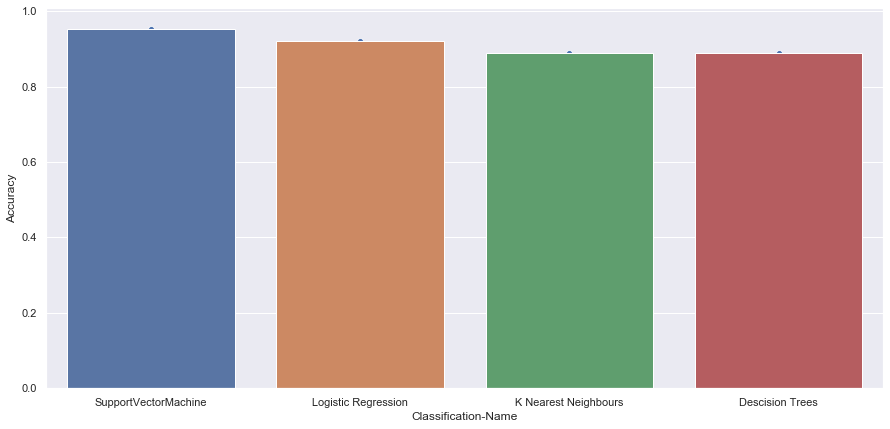

In [41]:


types=["SupportVectorMachine","Logistic Regression","K Nearest Neighbours","Descision Trees"]
classifiers=[grid,LogisticRegression(),grid2,DecisionTreeClassifier()]


accuracy= []
for name,clf in zip(types,classifiers):
    clf.fit(x_train,y_train)
    score=clf.score(x_test,y_test)
    accuracy.append(score)



df_check=pd.DataFrame()
df_check["Classification-Name"]=types
df_check["Accuracy"]=accuracy

plt.figure(figsize=(15, 7))
sns.set(style="darkgrid")
ax=sns.scatterplot(x="Classification-Name",y="Accuracy",data=df_check)
ax=sns.barplot(x="Classification-Name",y="Accuracy",data=df_check)  
#plotting the bar graph to betterly understand the best suitable method of classification
                                                                     

 


###### Hence, we can see that the accuracy of Support vector machine(SVM)is more  when compared to the other classifiers. Hence, SVM is the best method due to its highest accuracy. 

Note : We included the algorithm and future scope of improvement of in the Project Report.(.DOCX file)